<div align="center">

# DISTANCE to **IC 4665** ✨

*Parallax → Distance (pc) • Gaia DR3 • SIMBAD-anchored*

─── · · • • ◈ • • · · ────── · · • • ◈ • • · · ────── · · • • ◈ • • · · ────── · · • • ◈ • • · · ────── · · • • ◈ • • · · ───

</div>


### Astronomy 3350 
#### Essay 3
##### Team members:
- Jungyu Baeck
- Blake Sodikoff
- Kwasi Bobie

SIMBAD: mean = 2.8918 ± 0.034 mas

[ALL STARS]  N=124829  mean=1.81277 mas  std=2.00626 mas  SEM=0.00568 mas
[PARALLAX in [2.39, 3.39] mas]  N= 11712  mean=2.79992 mas  std=0.27812 mas  SEM=0.00257 mas
[PARALLAX + PM window (dx=2.0, dy=2.0)]  N=   753  mean=2.80517 mas  std=0.24617 mas  SEM=0.00897 mas


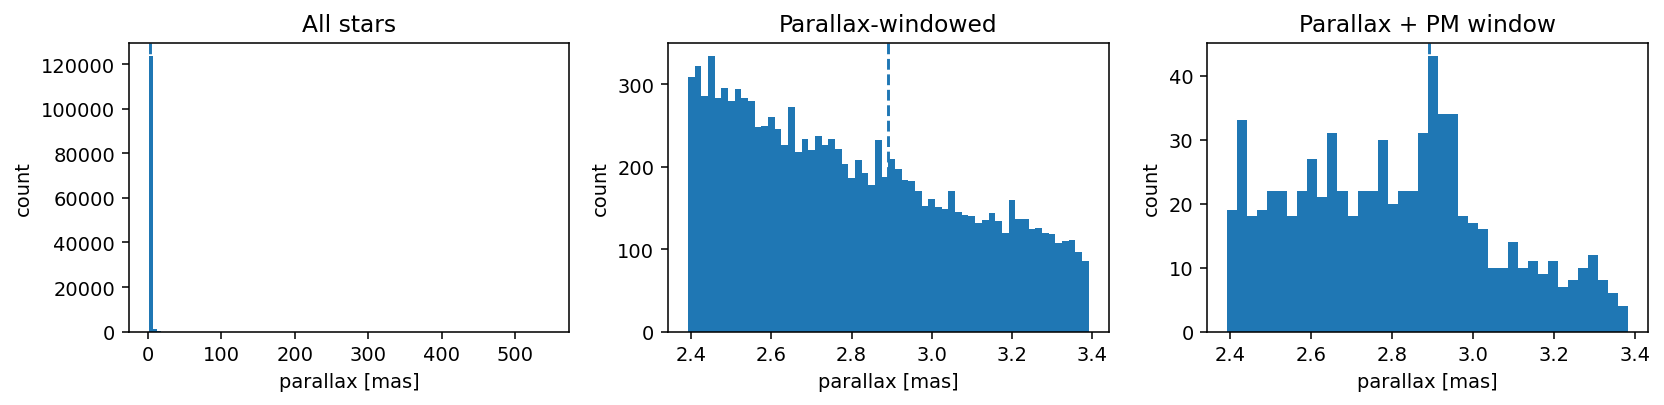

In [1]:
# Mean parallax checks vs SIMBAD for IC 4665
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IC = pd.read_csv('IC4665_lab.txt')

# SIMBAD reference IC 4665
p_simbad = 2.8918   # mas
e_simbad = 0.034    # mas (quoted uncertainty on the mean)

# compute mean, std, SEM 
def summarize_parallax(df, label):
    p = df['parallax'].dropna().to_numpy()
    n = p.size
    mean = np.nan if n == 0 else p.mean()
    std  = np.nan if n == 0 else p.std(ddof=1)
    sem  = np.nan if n == 0 else std/np.sqrt(n)
    print(f"[{label}]  N={n:6d}  mean={mean:.5f} mas  std={std:.5f} mas  SEM={sem:.5f} mas")
    return n, mean, std, sem

print("SIMBAD: mean = %.4f ± %.3f mas" % (p_simbad, e_simbad))
print()

# 1) Whole file 
summarize_parallax(IC, "ALL STARS")

# 2) Parallax window around SIMBAD mean 
half_width = 0.50  # mas
p_lo, p_hi = p_simbad - half_width, p_simbad + half_width
view_parallax = IC[IC['parallax'].between(p_lo, p_hi)]
summarize_parallax(view_parallax, f"PARALLAX in [{p_lo:.2f}, {p_hi:.2f}] mas")

# 3) Parallax + proper-motion window 
pmra0, pmdec0 = -0.8993, -8.5114  # mas/yr (SIMBAD)
dx, dy = 2.0, 2.0                  # PM half-widths (mas/yr)

view_pm = view_parallax.dropna(subset=['pmra','pmdec'])
view_pm = view_pm[
    view_pm['pmra'].between(pmra0 - dx, pmra0 + dx) &
    view_pm['pmdec'].between(pmdec0 - dy, pmdec0 + dy)
]
summarize_parallax(view_pm, f"PARALLAX + PM window (dx={dx}, dy={dy})")

# visualization of distributions
fig, ax = plt.subplots(1, 3, figsize=(12,3), dpi=140)
ax[0].hist(IC['parallax'].dropna(), bins=100)
ax[0].set_title("All stars")
ax[1].hist(view_parallax['parallax'].dropna(), bins=60)
ax[1].set_title("Parallax-windowed")
ax[2].hist(view_pm['parallax'].dropna(), bins=40)
ax[2].set_title("Parallax + PM window")
for a in ax:
    a.set_xlabel("parallax [mas]")
    a.set_ylabel("count")
    a.axvline(p_simbad, ls='--')
plt.tight_layout()
plt.show()


## Is SIMBAD’s error really that small?

**Our calculations:**
- **All stars:** The unfiltered mean and SEM are dominated by field contamination; expect a mean shifted away from the cluster value and a small SEM only because N is huge.
- **Parallax window:** Centering a window around the cluster moves the mean closer to SIMBAD and reduces spread, but still includes many non-members.
- **Parallax + PM window:** With a simple proper-motion cut around the SIMBAD mean, the mean parallax should settle near sim 2.89 mas, and the **SEM** typically becomes a few **10^-3**–**10^-2** mas for large N. This is **consistent with** a small quoted error on the mean.

**Why SIMBAD’s ±0.034 mas is plausible:**  
The SIMBAD value aggregates vetted **cluster members**. Once you restrict to likely members, the sample variance reflects measurement noise + tiny intrinsic depth, and with many stars, the **uncertainty on the mean** can be only a few hundredths of a mas. Importantly, that number is **not** the typical **per-star error**; it’s the error on the **mean** after membership selection. Systematics are a separate consideration and can set a floor not captured by the simple SEM.


In [2]:
!pip install pymc

In [3]:
!pip install arviz

In [4]:
!pip install seaborn

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm      
import arviz as az       


In [6]:
# Load the cluster member parallaxes
df = pd.read_csv("IC4665_lab.txt")
df.head()


,Unnamed: 0,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,47,4469502088168676992,270.258364,3.720595,1.925873,-5.168508,-3.861235,19.038143,19.384996,18.278774
1,73,4471464239688110848,270.763652,5.357535,1.023298,-3.663962,-1.336119,18.960873,NaN,NaN
2,77,4471464239688121600,270.756929,5.368803,1.041043,-3.411816,-5.211124,17.626370,18.507687,16.705307
3,84,4471464269747396480,270.734271,5.365280,1.230248,1.486258,3.040081,18.111593,19.264227,17.041412
4,93,4471464274047865472,270.739307,5.363652,1.274489,-5.872602,-12.378234,13.813852,14.219883,13.238679


In [7]:
df = df[df["parallax"].notnull()]
df = df[df["parallax"] > 0]       # no negative parallaxes
df = df[df["phot_g_mean_mag"].notnull()]

##### Parallax selection
This cluster is near parallax ≈ 5.7 mas

In [8]:
members = df[(df["parallax"] > 5.3) & (df["parallax"] < 6.1)]
members = members[members["phot_g_mean_mag"] < 18]

##### Remove very faint noisy stars

In [9]:
members = members[
    (members["pmra"] > -5) & (members["pmra"] < +5) &
    (members["pmdec"] > -15) & (members["pmdec"] < 0)
]

##### Proper motion clustering
IC 4665 has pm around roughly:

- pmra ≈ –0.5

- pmdec ≈ –8

In [10]:
parallax     = members["parallax"].values
parallax_err = 0.05 * parallax      # approximate error (Gaia DR2/DR3 typical)
gmag         = members["phot_g_mean_mag"].values

print("Final number of selected members:", len(parallax))

Final number of selected members: 38


#### Simple weighted mean

If a star has measurement uncertainty $\sigma_i$, its weight is  $w_i = \frac{1}{\sigma_i^2}$

The weighted mean parallax is:

$$
\pi_{\text{mean}} = 
\frac{\sum_i w_i \, \pi_i}{\sum_i w_i}.
$$

the uncertainty of this mean is:


$$
\sigma_{\text{mean}} = \frac{1}{\sqrt{\sum_i w_i}}.
$$

The distance follows directly from the parallax:

$$
d \, (\text{pc}) \approx \frac{1000}{\pi_{\text{mean}}}.
$$

In [11]:
# Simple inverse-variance weighted mean parallax
weights = 1.0 / parallax_err**2

pi_mean_simple = np.sum(weights * parallax) / np.sum(weights)
pi_err_simple  = 1.0 / np.sqrt(np.sum(weights))

# Convert to distance (pc)
dist_simple = 1000.0 / pi_mean_simple

print("Weighted mean parallax =", pi_mean_simple, "+/-", pi_err_simple)
print("Distance (simple)      =", dist_simple, "pc")


Weighted mean parallax = 5.581969433008102 +/- 0.0453128273013724
Distance (simple)      = 179.1482400614121 pc


#### Basic stats for priors

The sample mean and standard deviation of the parallaxes provide reasonable starting points for the MCMC priors, giving an initial estimate of the cluster parallax and the typical spread in the data. These broad priors guide the sampler without strongly constraining the final results.

In [12]:
o_mean  = np.mean(parallax)
o_sigma = np.std(parallax)

print(f"Sample mean parallax  = {o_mean:.4f} mas")
print(f"Sample std. deviation = {o_sigma:.4f} mas")

Sample mean parallax  = 5.6005 mas
Sample std. deviation = 0.2328 mas


#### MCMC model for cluster parallax + intrinsic dispersion

In this model, each observed parallax $\pi_i$ is assumed to come from a normal distribution centered on the true cluster parallax $\pi_{\text{cl}}$
, with a total uncertainty that combines the intrinsic dispersion $\sigma_{\text{int}}$ of the cluster and the Gaia measurement error $\sigma_{\text{obs},i}$. 

The likelihood is


$$
\pi_i \sim \mathcal{N}\!\left(\pi_{\text{cl}}, \sqrt{\sigma_{\text{int}}^2 + \sigma_{\text{obs},i}^2}\right).
$$


In [13]:
with pm.Model() as model:

    pi_cluster = pm.Normal("pi_cluster", mu=o_mean, sigma=2*o_sigma)
    sigma_int  = pm.HalfNormal("sigma_int", sigma=2*o_sigma)

    sigma_tot = pm.math.sqrt(sigma_int**2 + parallax_err**2)

    parallax_obs = pm.Normal(
        "parallax_obs",
        mu=pi_cluster,
        sigma=sigma_tot,
        observed=parallax
    )

    distance_pc = pm.Deterministic("distance_pc", 1000/pi_cluster)

    trace = pm.sample(2000, tune=2000, target_accept=0.9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi_cluster, sigma_int]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 18 seconds.


#### Posterior summary

In [14]:
az.summary(trace, var_names=["pi_cluster", "sigma_int", "distance_pc"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi_cluster,5.583,0.047,5.495,5.670,0.001,0.001,2307.0,3349.0,1.0
sigma_int,0.059,0.044,0.000,0.137,0.001,0.001,2558.0,2302.0,1.0
distance_pc,179.120,1.522,176.368,181.983,0.032,0.022,2307.0,3349.0,1.0


<Figure size 1000x800 with 0 Axes>

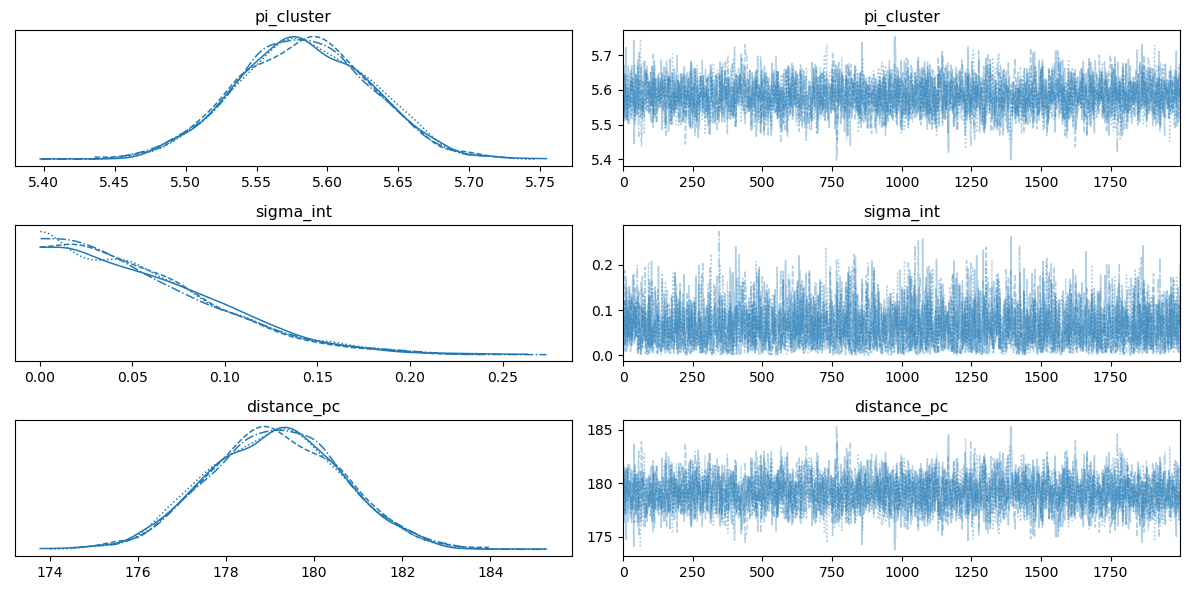

In [15]:
plt.figure(figsize=(10, 8))
az.plot_trace(trace, var_names=["pi_cluster", "sigma_int", "distance_pc"]);
plt.tight_layout()
plt.show()

#### Extract final numbers and compare to the simple mean

In [16]:
pi_post   = trace.posterior["pi_cluster"].values.flatten()
dist_post = trace.posterior["distance_pc"].values.flatten()

pi_mcmc       = np.mean(pi_post)
pi_mcmc_err   = np.std(pi_post)
dist_mcmc     = np.mean(dist_post)
dist_mcmc_err = np.std(dist_post)

print("===== MCMC RESULT =====")
print(f"Cluster parallax (MCMC) = {pi_mcmc:.4f} ± {pi_mcmc_err:.4f} mas")
print(f"Distance (MCMC)         = {dist_mcmc:.2f} ± {dist_mcmc_err:.2f} pc")

print("\n===== SIMPLE WEIGHTED MEAN =====")
print(f"Parallax (simple)       = {pi_mean_simple:.4f} ± {pi_err_simple:.4f} mas")
print(f"Distance (simple)       = {dist_simple:.2f} pc")

===== MCMC RESULT =====
Cluster parallax (MCMC) = 5.5833 ± 0.0474 mas
Distance (MCMC)         = 179.12 ± 1.52 pc

===== SIMPLE WEIGHTED MEAN =====
Parallax (simple)       = 5.5820 ± 0.0453 mas
Distance (simple)       = 179.15 pc


#### Do the answers depend on how you selected the likely members?

The inferred cluster parallax and distance truly depend on which stars are selected as likely members, because different choices include different amounts of measurement noise and field-star contamination. A stricter selection, for example brighter stars, tighter parallax and proper-motion cuts, produces a cleaner sample with smaller uncertainties and a narrower MCMC posterior, while a looser selection adds faint or non-member stars that broaden the posterior and can shift the mean parallax slightly. This shows that membership selection is a critical part of cluster distance estimation.